# 03 - data preprocessing

**purpose**: parse 7-part RAVDESS filenames, build per-actor train/val/test split, preprocess audio (16kHz mono, 4s, RMS-normalized). **6 shared emotions** (neutral, calm, happy, sad, angry, fearful). **speech + song** channels merged.

**input**: 2452 .wav files in `data/raw/` (1440 speech + 1012 song)

**output**: 2068 .npy files in `data/processed/audio/{train,val,test}/{speech,song}/Actor_*/` (1628 train + 264 val + 176 test, after dropping disgust+surprised for 6-class)

In [1]:
import sys
import os
os.chdir('../../')
sys.path.append('../../')
print(f"Changed working directory to '../../': {os.getcwd()}")

Changed working directory to '../../': e:\career\projects\lightweight-speech-emotion-recognition-on-open-datasets


**import preprocessing modules**. we bring in numpy for array ops, librosa for audio processing, pandas for dataframes, and the project's settings and preprocessing helpers.

In [2]:
import numpy as np
import pandas as pd
import librosa
import shutil
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
from src.config.config import settings
from src.utils.data_preprocessing import preprocess_audio, parse_filename, build_split_dataframe, save_split


**display audio processing parameters**. the project uses 16 khz sample rate and 4-second clips (64000 samples). training/validation/test actor ids are shown for reference.

In [3]:
print(f"SR = {settings.SAMPLE_RATE} Hz")
print(f"Duration = {settings.DURATION} sec")
print(f"N_samples = {settings.N_SAMPLES}")
print(f"Train actors: {settings.TRAIN_ACTORS}")
print(f"Val actors:   {settings.VAL_ACTORS}")
print(f"Test actors:  {settings.TEST_ACTORS}")

SR = 16000 Hz
Duration = 4.0 sec
N_samples = 64000
Train actors: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Val actors:   [20, 21, 22]
Test actors:  [23, 24]


**test preprocessing on one file**. we grab an arbitrary wav file and run the preprocessing pipeline (resample to 16khz, convert to mono, trim/pad to 4 seconds, rms-normalize) to verify it works.

In [4]:
test_file  = list(settings.RAW_DIR.rglob("*.wav"))[100]
test_audio = preprocess_audio(test_file)

c:\Users\Admin\miniconda3\envs\speechrecog\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**inspect preprocessed audio**. after preprocessing, the audio should be exactly 64000 samples long and normalized to [-1, 1] range.

In [5]:
print(f"Shape: {test_audio.shape}")
print(f"Min: {test_audio.min():.3f}, Max: {test_audio.max():.3f}")

Shape: (64000,)
Min: -1.000, Max: 1.000


**load original audio for comparison**. we load the same file with librosa at its native sample rate to compare original vs processed waveforms.

In [6]:
test_file = list(settings.RAW_DIR.rglob("*.wav"))[100]
audio_orig, sr_orig = librosa.load(test_file, sr=None, mono=True)
audio_processed = preprocess_audio(test_file)

**compare durations**. the original file might be ~4.8 seconds; we trim/pad it to exactly 4.0 seconds. this ensures all inputs to the model have the same length.

In [7]:
print(f"File: {test_file.name}")
print(f"Original duration:  {len(audio_orig)/sr_orig:.2f} sec")
print(f"Processed duration: {len(audio_processed)/settings.SAMPLE_RATE:.2f} sec")

File: 03-02-03-01-01-01-03.wav
Original duration:  4.80 sec
Processed duration: 4.00 sec


**plot original vs processed waveforms**. we compare the raw and processed waveforms side-by-side. the processed version is shorter (4s), has fewer samples (16khz vs original rate), and is amplitude-normalized.

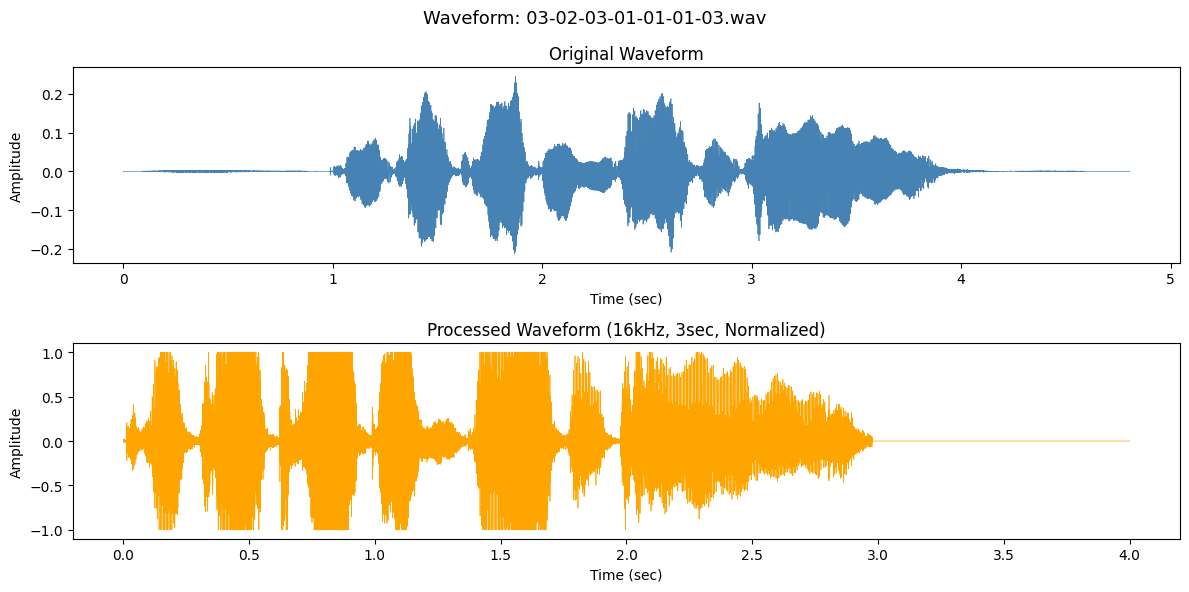

Done!


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
fig.suptitle(f'Waveform: {test_file.name}', fontsize=13)

axes[0].plot(np.linspace(0, len(audio_orig)/sr_orig, len(audio_orig)), 
             audio_orig, color='steelblue', linewidth=0.5)
axes[0].set_title('Original Waveform')
axes[0].set_xlabel('Time (sec)')
axes[0].set_ylabel('Amplitude')

axes[1].plot(np.linspace(0, settings.DURATION, len(audio_processed)), 
             audio_processed, color='orange', linewidth=0.5)
axes[1].set_title('Processed Waveform (16kHz, 3sec, Normalized)')
axes[1].set_xlabel('Time (sec)')
axes[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig(str(settings.FIGURES_DIR / 'fig03-waveform_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Done!")

## Spectrogram Visualization

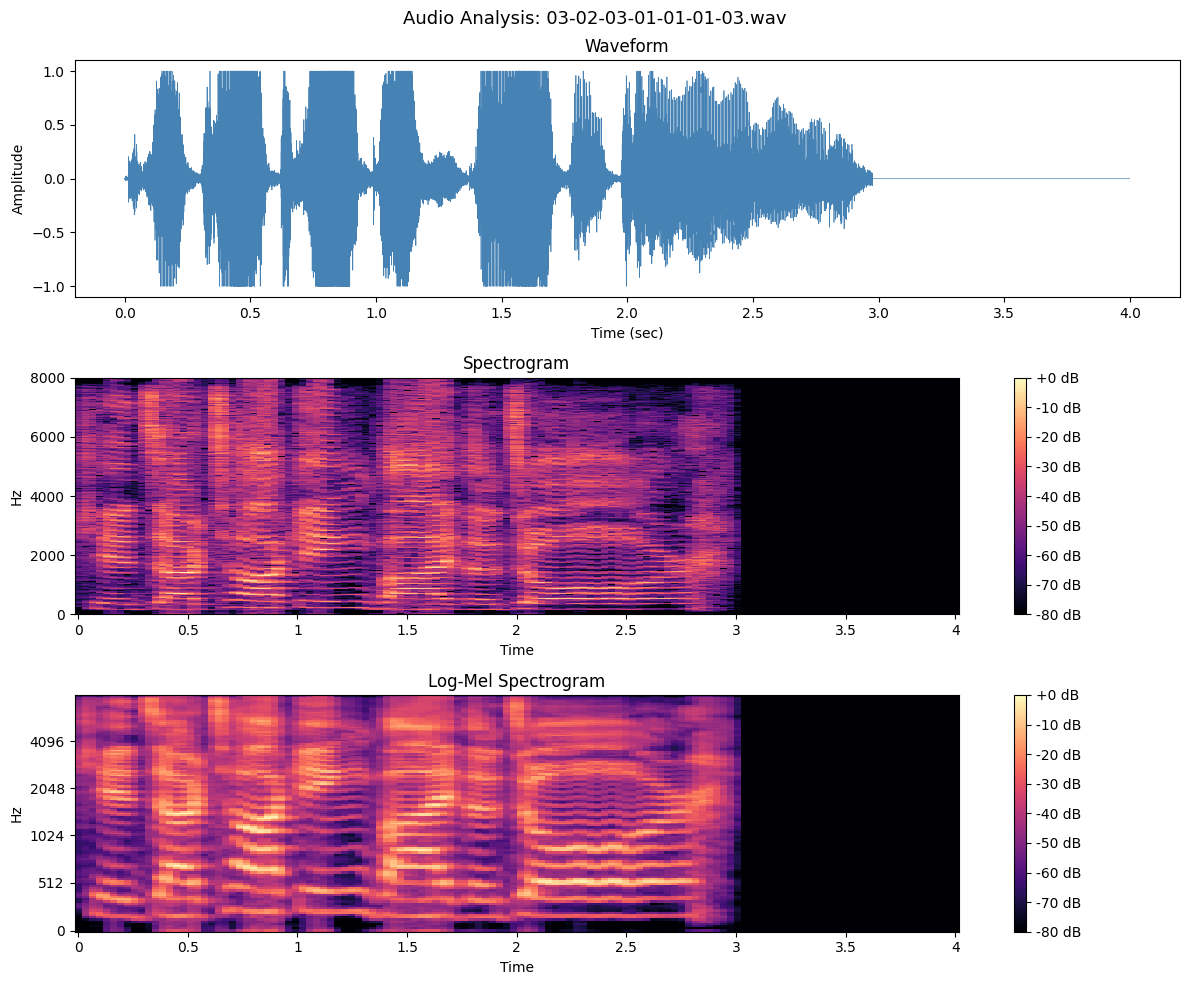

Done!


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle(f'Audio Analysis: {test_file.name}', fontsize=13)

axes[0].plot(np.linspace(0, settings.DURATION, len(test_audio)), 
             test_audio, color='steelblue', linewidth=0.5)
axes[0].set_title('Waveform')
axes[0].set_xlabel('Time (sec)')
axes[0].set_ylabel('Amplitude')

D = librosa.amplitude_to_db(
    np.abs(librosa.stft(test_audio)), ref=np.max)
img = librosa.display.specshow(D, sr=settings.SAMPLE_RATE, x_axis='time', 
                                y_axis='hz', ax=axes[1])
axes[1].set_title('Spectrogram')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

mel = librosa.feature.melspectrogram(y=test_audio, sr=settings.SAMPLE_RATE, 
                                      n_mels=settings.N_MELS)
mel_db = librosa.power_to_db(mel, ref=np.max)
img2 = librosa.display.specshow(mel_db, sr=settings.SAMPLE_RATE, x_axis='time',
                                 y_axis='mel', ax=axes[2])
axes[2].set_title('Log-Mel Spectrogram')
fig.colorbar(img2, ax=axes[2], format='%+2.0f dB')

plt.tight_layout()
plt.savefig(str(settings.FIGURES_DIR / 'fig03-spectrogram_analysis.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Done!")

**select one file per emotion**. we pick one speech file for each of the 6 target emotions to compare their spectrograms visually.

In [10]:
emotions_to_show = ['neutral', 'happy', 'sad', 'angry', 'fearful']
files_to_show = []

**collect target files**. we iterate through the raw directory to find a speech recording for each emotion label.

In [11]:
for emotion in emotions_to_show:
    emotion_files = list(settings.RAW_DIR.rglob("*.wav"))
    for f in emotion_files:
        parts = f.stem.split('-')
        if len(parts) == 7:
            emo_id = int(parts[2])
            emo_name = settings.EMOTION_MAP.get(emo_id, 'unknown')
            if emo_name == emotion and parts[1] == '01':
                files_to_show.append((emotion, f))
                break

**plot log-mel spectrograms per emotion**. we compare spectrograms across emotions side-by-side. this gives an intuitive sense of whether emotions produce distinguishable acoustic patterns.

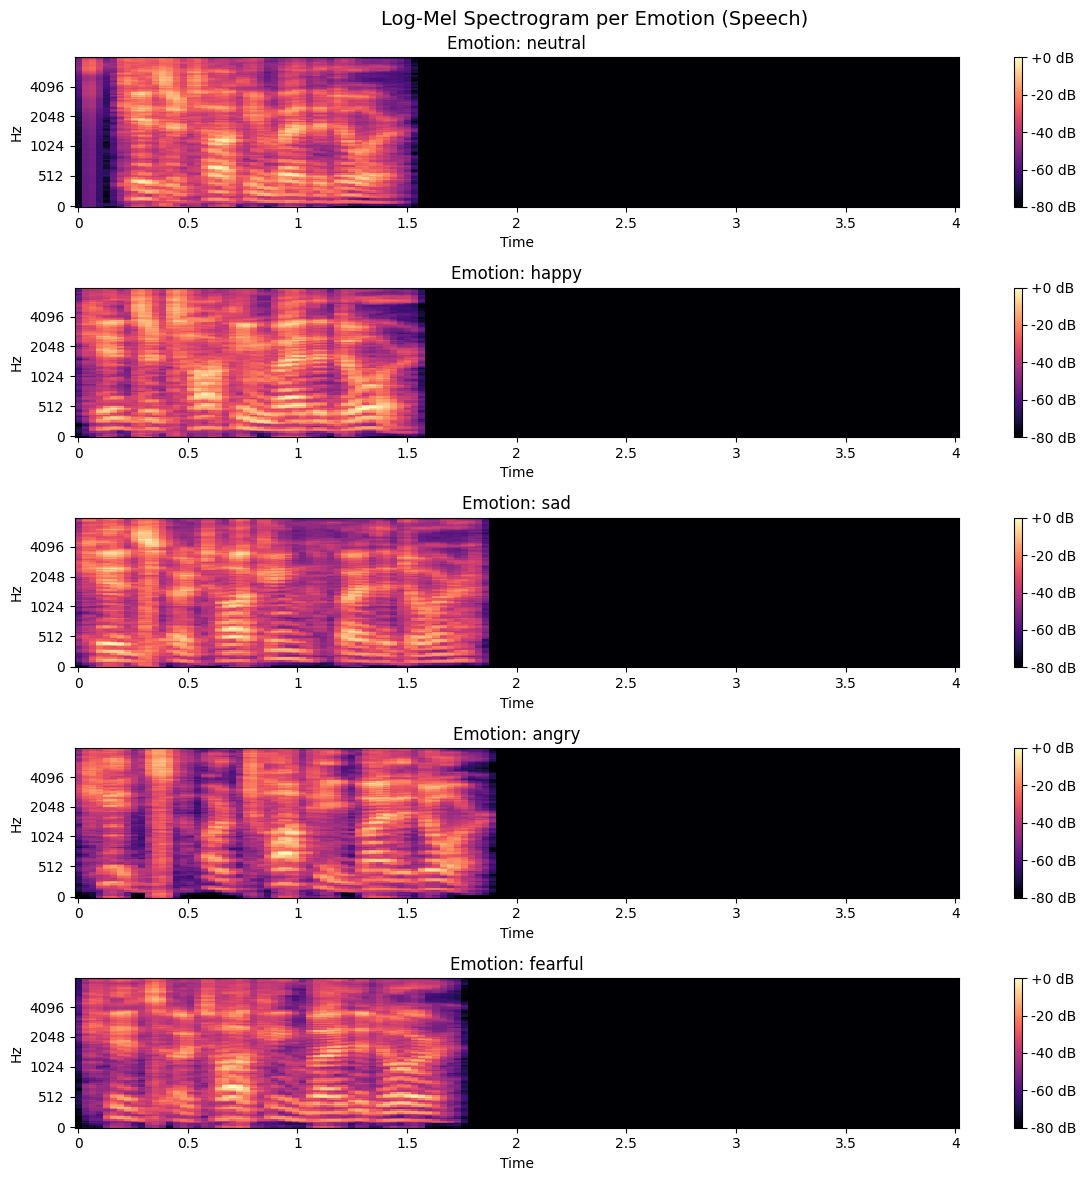

Done!


In [12]:
fig, axes = plt.subplots(len(files_to_show), 1, figsize=(12, 12))
fig.suptitle('Log-Mel Spectrogram per Emotion (Speech)', fontsize=14)

for i, (emotion, filepath) in enumerate(files_to_show):
    audio = preprocess_audio(filepath)
    mel = librosa.feature.melspectrogram(y=audio, sr=settings.SAMPLE_RATE, n_mels=settings.N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    img = librosa.display.specshow(mel_db, sr=settings.SAMPLE_RATE, 
                                    x_axis='time', y_axis='mel',
                                    ax=axes[i])
    axes[i].set_title(f'Emotion: {emotion}')
    fig.colorbar(img, ax=axes[i], format='%+2.0f dB')

plt.tight_layout()
plt.savefig(str(settings.FIGURES_DIR / 'fig03-emotions_spectrograms.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Done!")

build split dataframes

In [13]:
train_df, val_df, test_df = build_split_dataframe(settings.RAW_DIR)
print(f"train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

train: 1628, val: 264, test: 176


**preprocess all audio files**. we iterate through all files in each split and run the preprocessing pipeline. each file is saved as a `.npy` array in `data/processed/audio/`. this takes a minute or two.

In [14]:
print("starting preprocessing...")
save_split(train_df, settings.AUDIO_TRAIN_DIR, "Train")
save_split(val_df,   settings.AUDIO_VAL_DIR,   "Val")
save_split(test_df,  settings.AUDIO_TEST_DIR,  "Test")
print("all done!")

starting preprocessing...
all done!
